<a href="https://colab.research.google.com/github/AhmadFebriyan5/menjalankan-code_machine-Learning/blob/main/bab_3_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 3 Unsupervised Learning and Preprocessing

Di bab ini membahas preprocessing, scaling, Principal Component Analysis (PCA), dan beberapa algoritma clustering.
Pada unsupervised learning, data tidak memiliki label target yang digunakan secara langsung saat pelatihan.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score

print("Library berhasil diimpor.")


Library berhasil diimpor.


## 1. Melihat Pengaruh Scaling

Scaling menyamakan skala fitur supaya fitur dengan nilai besar tidak mendominasi proses pembelajaran. Dua metode yang umum digunakan yaitu StandardScaler dan MinMaxScaler.


In [2]:
iris = load_iris()
X = iris.data
y = iris.target

scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

print("Rata-rata setelah StandardScaler:", X_standard.mean(axis=0))
print("Minimum setelah MinMaxScaler:", X_minmax.min(axis=0))
print("Maksimum setelah MinMaxScaler:", X_minmax.max(axis=0))


Rata-rata setelah StandardScaler: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Minimum setelah MinMaxScaler: [0. 0. 0. 0.]
Maksimum setelah MinMaxScaler: [1. 1. 1. 1.]


## 2. Visualisasi Data Sebelum dan Sesudah Scaling

Di grafik ini ada dua fitur pertama sebelum dan sesudah standardisasi.


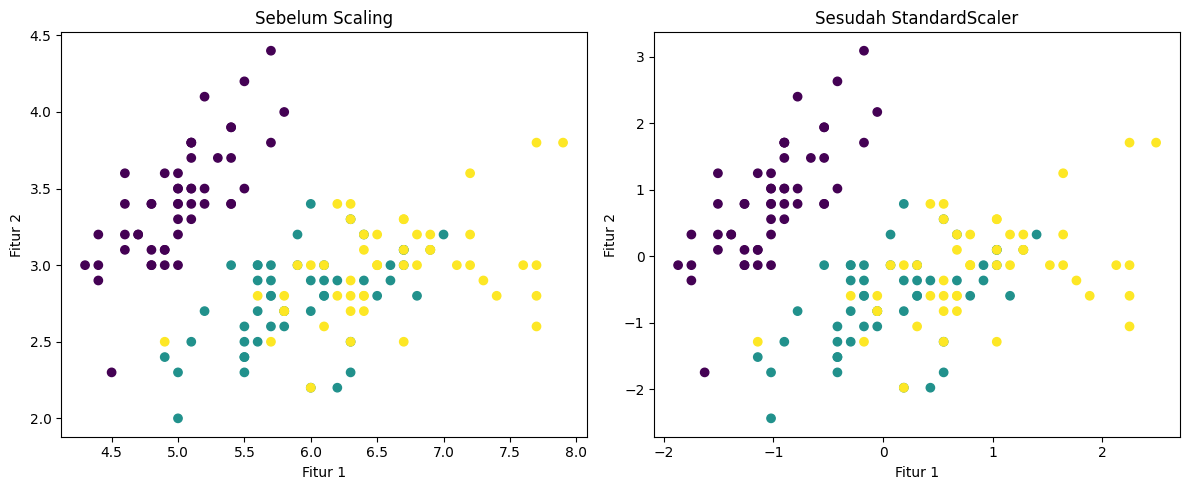

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=y)
axes[0].set_title("Sebelum Scaling")
axes[0].set_xlabel("Fitur 1")
axes[0].set_ylabel("Fitur 2")

axes[1].scatter(X_standard[:, 0], X_standard[:, 1], c=y)
axes[1].set_title("Sesudah StandardScaler")
axes[1].set_xlabel("Fitur 1")
axes[1].set_ylabel("Fitur 2")

plt.tight_layout()
plt.show()


## 3. Principal Component Analysis (PCA)

PCA mengubah sejumlah fitur menjadi komponen baru. Komponen tersebut disusun berdasarkan jumlah variasi data yang dapat dijelaskan. PCA sering digunakan untuk reduksi dimensi dan visualisasi.


Bentuk data sebelum PCA: (150, 4)
Bentuk data setelah PCA: (150, 2)
Explained variance ratio: [0.72962445 0.22850762]
Total variasi yang dijelaskan: 0.9581320720000166


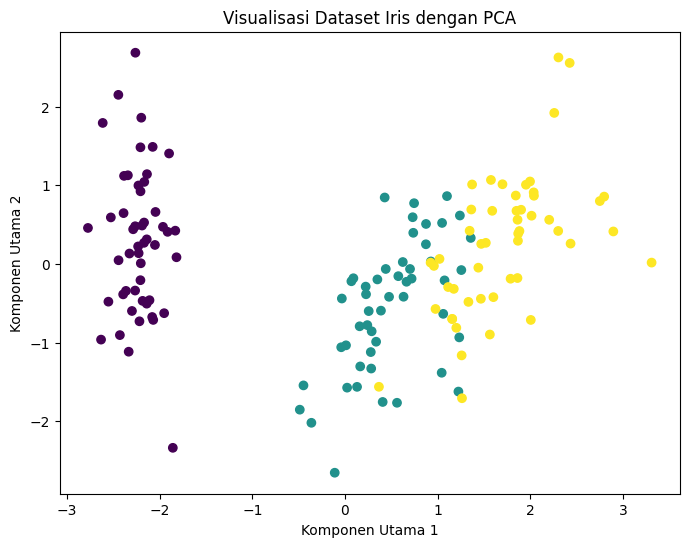

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standard)

print("Bentuk data sebelum PCA:", X_standard.shape)
print("Bentuk data setelah PCA:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variasi yang dijelaskan:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Komponen Utama 1")
plt.ylabel("Komponen Utama 2")
plt.title("Visualisasi Dataset Iris dengan PCA")
plt.show()


## 4. Membuat Data untuk Clustering

Clustering mengelompokkan data berdasarkan kemiripan tanpa menggunakan label target saat proses pembentukan kelompok.


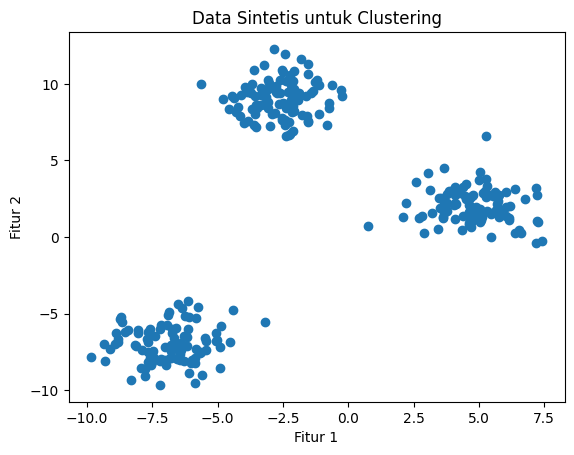

In [5]:
X_cluster, y_cluster = make_blobs(
    n_samples=300, centers=3, cluster_std=1.2, random_state=42
)

plt.scatter(X_cluster[:, 0], X_cluster[:, 1])
plt.title("Data Sintetis untuk Clustering")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()


## 5. K-Means Clustering

K-Means membagi data ke dalam sejumlah kelompok yang ditentukan melalui parameter `n_clusters`. Setiap data akan ditempatkan pada cluster dengan pusat terdekat.


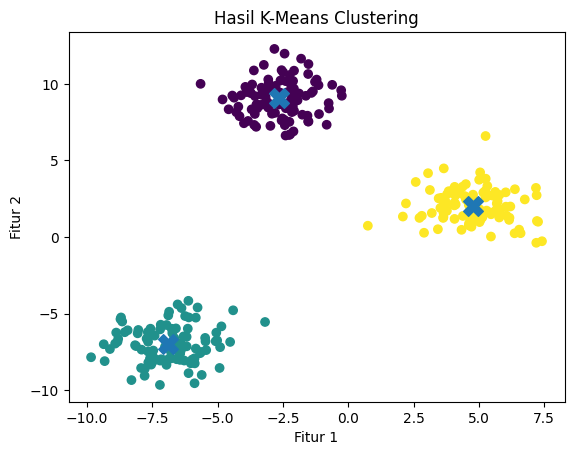

Adjusted Rand Index: 1.0


In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
label_kmeans = kmeans.fit_predict(X_cluster)

plt.scatter(
    X_cluster[:, 0], X_cluster[:, 1],
    c=label_kmeans, cmap="viridis"
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X", s=200
)
plt.title("Hasil K-Means Clustering")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

print("Adjusted Rand Index:", adjusted_rand_score(y_cluster, label_kmeans))


## 6. Agglomerative Clustering

Agglomerative Clustering membentuk kelompok secara bertahap. Pada awalnya setiap data dianggap sebagai satu cluster, kemudian cluster yang paling dekat digabungkan hingga jumlah cluster yang diinginkan tercapai.


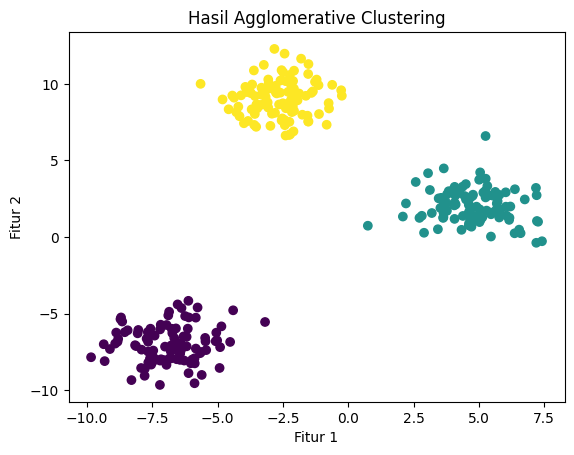

Adjusted Rand Index: 1.0


In [7]:
agglo = AgglomerativeClustering(n_clusters=3)
label_agglo = agglo.fit_predict(X_cluster)

plt.scatter(
    X_cluster[:, 0], X_cluster[:, 1],
    c=label_agglo, cmap="viridis"
)
plt.title("Hasil Agglomerative Clustering")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

print("Adjusted Rand Index:", adjusted_rand_score(y_cluster, label_agglo))


## 7. DBSCAN

DBSCAN membentuk cluster berdasarkan kepadatan data. Algoritma ini dapat menemukan kelompok dengan bentuk yang tidak beraturan dan dapat menandai beberapa data sebagai noise.


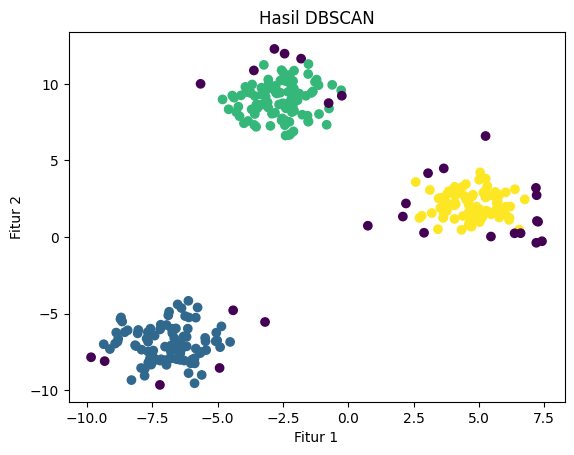

Jumlah cluster: 3
Jumlah data noise: 29


In [8]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
label_dbscan = dbscan.fit_predict(X_cluster)

plt.scatter(
    X_cluster[:, 0], X_cluster[:, 1],
    c=label_dbscan, cmap="viridis"
)
plt.title("Hasil DBSCAN")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

jumlah_cluster = len(set(label_dbscan)) - (1 if -1 in label_dbscan else 0)
jumlah_noise = list(label_dbscan).count(-1)

print("Jumlah cluster:", jumlah_cluster)
print("Jumlah data noise:", jumlah_noise)


## 8. Perbandingan Hasil Clustering

Adjusted Rand Index digunakan di sini sebagai evaluasi tambahan karena dataset sintetis memiliki label pembanding. Dalam kasus nyata, label seperti ini biasanya tidak tersedia.


In [9]:
hasil_clustering = pd.DataFrame({
    "Algoritma": ["K-Means", "Agglomerative", "DBSCAN"],
    "Adjusted Rand Index": [
        adjusted_rand_score(y_cluster, label_kmeans),
        adjusted_rand_score(y_cluster, label_agglo),
        adjusted_rand_score(y_cluster, label_dbscan)
    ]
})

display(hasil_clustering)


,Algoritma,Adjusted Rand Index
0,K-Means,1.000000
1,Agglomerative,1.000000
2,DBSCAN,0.852826


## Kesimpulan Bab 3

Preprocessing membantu menyiapkan data sebelum digunakan oleh algoritma machine learning. StandardScaler dan MinMaxScaler dapat digunakan untuk menyamakan skala fitur. PCA dapat mengurangi jumlah dimensi sekaligus mempertahankan sebagian besar variasi data. Sementara itu, K-Means, Agglomerative Clustering, dan DBSCAN dapat digunakan untuk menemukan kelompok data tanpa label target.
